<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/ADALL_Week5_Model_Eval_Practical_Test_Revision_v2(ANNIE).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color = 'red'>**dated 25.07.2026 8pm**

# ADALL Practical Test Revision: Regression Workflow

## Single-session version

This notebook is designed for **one revision session**.

The main route is short. Read the optional sections only after you finish the main route.

### Session target
By the end of this session, you should be able to:

1. explain why this is a **regression** task,
2. create the target `num_failed_subjects`,
3. avoid leakage from `G1`, `G2`, and `G3`,
4. create a dataset profile for LLM review,
5. train models using a pipeline,
6. compare results using CV and holdout MAE,
7. write a short judgement-based answer.

### Suggested timing

| Part | Time |
|---|---:|
| Admin and test reminder | 10 to 15 min |
| Main route in this notebook | 75 to 90 min |
| Recap and Q&A | 15 to 20 min |
| Optional practice | After class |

<div style="background-color:#eaf4ff; border-left:6px solid #2b7bbb; padding:12px;">
<strong>Main idea:</strong> The practical test is not mainly about writing many new lines of code. It is about knowing what the code is doing, running the right block, checking the result, and explaining your decision clearly.
</div>


## What the previous lecturer focused on

The transcript suggests that this revision should focus on the following points:

| Focus area | What students should pay attention to |
|---|---|
| Regression only | The practical test focuses on predicting a number, not classification. |
| Read instructions carefully | If a cell says “run only”, do not edit it unnecessarily. |
| Dataset profile and payload text | You should know how to summarise the dataset for LLM-assisted review. |
| Leakage | `G1`, `G2`, and `G3` directly define the target, so they must not be used as predictors. |
| Train/test split | Keep the test set for final checking. Use a fixed `random_state`. |
| Pipeline | Use the same preprocessing and modelling structure fairly. |
| Model comparison | Choose based on evidence, not because a model sounds more advanced. |

<div style="background-color:#fff8e6; border-left:6px solid #d69b00; padding:12px;">
<strong>Revision stance:</strong> You are practising judgement. Do not accept every LLM recommendation automatically. Check whether the recommendation makes sense for the task.
</div>


## Step 0. Setup

Run this cell first.

Do not edit the imports unless you get a clear library error.


In [2]:
# Core libraries
import os
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Modelling
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

RANDOM_STATE = 42

print('Setup complete')


Setup complete


### What to check after Step 0

You should see no error.

If there is an error, it is usually because a library is not installed in the runtime. In Colab, install the missing library, restart the runtime if needed, then run the setup again.


## Step 1. Load the dataset and do quick checks

The practical test may provide the loading code for you.

When the instruction says **run the cell**, just run it first. Do not rewrite the loading code unless the question asks you to.

In this revision notebook, we use the student performance dataset.


In [3]:
#Load dataset from github
#github_raw_url = 'https://raw.githubusercontent.com/rq-goh/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'
#df = pd.read_csv(github_raw_url)

# Load data from KaggleHub
# In the actual practical test, the dataset path/code may be provided to you.

import kagglehub

path = kagglehub.dataset_download("devansodariya/student-performance-data")
print("Downloaded to:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(os.path.join(path, "student_data.csv"))
df.head()


Using Colab cache for faster access to the 'student-performance-data' dataset.
Downloaded to: /kaggle/input/student-performance-data
Files: ['student_data.csv']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
# Quick checks
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData info:")
df.info()


Shape: (395, 33)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11

### What to check after Step 1

Check these before moving on:

1. Does the dataset load correctly?
2. How many rows and columns are there?
3. Are `G1`, `G2`, and `G3` present?
4. Are there missing values?
5. Which columns are numeric and which are categorical?

Short answer format:

```text
The dataset has ___ rows and ___ columns. It contains a mix of numeric and categorical columns. The grade columns are G1, G2 and G3.
```


## Step 2. Create a dataset profile for LLM review

A dataset profile is a text summary of the dataset.

You use it so the LLM does not need the full dataset. It can review the structure, missing values, data types, correlations, and possible risks.

### What the payload should include

- dataset shape,
- column data types,
- numeric summary,
- categorical summary,
- missing values,
- unique value counts,
- simple correlation information,
- possible leakage clues.

<div style="background-color:#fff0f0; border-left:6px solid #d93636; padding:12px;">
<strong>Important:</strong> The LLM recommendation is not automatically correct. You still need to decide whether each recommendation is sensible.
</div>


In [ ]:
from io import StringIO

buffer = StringIO()

buffer.write("=== SHAPE ===\n")
buffer.write(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n\n")

buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

buffer.write("=== CATEGORICAL DESCRIBE ===\n")
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    buffer.write(df[cat_cols].describe().to_string())
else:
    buffer.write("No categorical columns")
buffer.write("\n\n")

buffer.write("=== NULL SUMMARY ===\n")
null_summary = df.isna().sum().to_frame("null_count")
null_summary["null_pct"] = null_summary["null_count"] / len(df)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

buffer.write("=== CORRELATIONS: NUMERIC ONLY ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

buffer.write("=== POSSIBLE UNIQUE-ID COLUMNS ===\n")
unique_id_cols = df.columns[df.nunique() == len(df)].tolist()
buffer.write(str(unique_id_cols))
buffer.write("\n")

payload_text = buffer.getvalue()
print(payload_text)


=== SHAPE ===
Rows: 395, Columns: 33

=== DTYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64

=== NUMERIC DESCRIBE ===
              age        Medu        Fedu  traveltime   studytime    failures      famrel    freetime       goout        Dalc        Walc      health    absences          G1          G2          G3
count  395.000000  395.000000 

In [ ]:
# ANNIE's CODE to BUILD PAYLOAD TEXT
# Build payload text step by step.
# Payload text is a short profile of the dataset.
# It is safer and smaller than sending the full dataset to the LLM.

payload_text = ''

# 0. Objective
payload_text += '=== OBJECTIVE ===\n'
payload_text += 'Context: The Dataset consists of Student Performance Data obtained in a survey of students performance in math course in secondary school.\n'
payload_text += ' It consists of 33 Column Features like:school ID, gender, age, size of family, Father education, Mother education, Occupation of Father and Mother, Family Relation, Health, Grades.\n'

payload_text += 'Goal: Your target is a count: number of subjects failed (based on scores below 10 from G1, G2, G3).\n'

payload_text += 'Questions:\n'
payload_text += '- What does each row appear to represent?\n'
payload_text += '- Which features influence the target?\n'
payload_text += '- What data quality issues exist?\n'
payload_text += '- What preprocessing is required?\n\n'

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Sample records
payload_text += '=== SAMPLE RECORDS ===\n'
payload_text += df.head(5).to_string(index=False)
payload_text += '\n\n'

# 3. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 4. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 5. Null summary
payload_text += "=== NULL SUMMARY ===\n"
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
payload_text += null_summary.to_string()
payload_text += '\n\n'

# 6. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 7. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 8 Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 9. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 10. Skewness of numeric columns
payload_text += '=== SKEWNESS OF NUMERIC COLUMNS ===\n'
skew_table = df.select_dtypes(include='number').skew().round(2)
payload_text += skew_table.to_string()
payload_text += '\n\n'

# 11. Outlier summary
payload_text += '=== OUTLIER SUMMARY (IQR METHOD) ===\n'

numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_pct = round(outlier_count / len(df) * 100, 2)

    payload_text += f'{column}: {outlier_count} ({outlier_pct}%)\n'

payload_text += '\n'

# 12. Leakage scan: columns with all unique values
payload_text += "=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n"
leak_cols = df.columns[df.nunique() == len(df)]
payload_text +=str(list(leak_cols))
payload_text +="\n\n"

# 13. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)
payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)
payload_text += (
    f'Duplicate rows: {duplicate_count} ({duplicate_pct}%)\n'
)

print(payload_text)


=== OBJECTIVE ===
Context: The Dataset consists of Student Performance Data obtained in a survey of students performance in math course in secondary school.
 It consists of 33 Column Features like:school ID, gender, age, size of family, Father education, Mother education, Occupation of Father and Mother, Family Relation, Health, Grades.
Goal: Your target is a count: number of subjects failed (based on scores below 10 from G1, G2, G3).
Questions:
- What does each row appear to represent?
- Which features influence the target?
- What data quality issues exist?
- What preprocessing is required?

=== SHAPE ===
Rows: 395
Columns: 33

=== SAMPLE RECORDS ===
school sex  age address famsize Pstatus  Medu  Fedu    Mjob     Fjob reason guardian  traveltime  studytime  failures schoolsup famsup paid activities nursery higher internet romantic  famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  G3
    GP   F   18       U     GT3       A     4     4 at_home  teacher course   mother     

### What to check after Step 2

Your payload should be readable.

Check that it contains enough information for a reviewer to answer:

1. What is the dataset size?
2. What are the main column types?
3. Are there missing values?
4. Are there possible leakage columns?
5. Are `G1`, `G2`, and `G3` strongly related to the target you plan to create?


## Step 3. Ask the LLM a small, focused question

Do not ask the LLM to solve everything at once.

Start with a small review question:

> “Based on this dataset profile and the target definition, what data risks should I check before modelling?”

The aim is to get a review, not to blindly follow instructions.


In [4]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

# Only use this section if your tutor has asked you to call the API from Colab.
# You must first save OPENAI_API_KEY in Colab Secrets.

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


In [ ]:
llm_prompt = f"""
You are helping me review a regression dataset for a practical test revision.

Task:
I want to predict the number of failed subjects.
A subject is failed when its grade is below 10.
The grade columns are G1, G2 and G3.

Dataset profile:
{payload_text}

Please answer in three sections:
1. Data quality issues to check before modelling.
2. Columns that may cause leakage, with reasons.
3. Which recommendations need human judgement before applying.

Keep the answer concise. Do not write modelling code yet.
"""
print('\n=====Prompt to send =====')
print(llm_prompt)

if client is not None:
    llm_response = client.responses.create(
        model=OPENAI_MODEL,
        input=llm_prompt
    )
    print('\n=====LLM response=====')
    print(llm_response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



=====Prompt to send =====

You are helping me review a regression dataset for a practical test revision.

Task:
I want to predict the number of failed subjects.
A subject is failed when its grade is below 10.
The grade columns are G1, G2 and G3.

Dataset profile:
=== OBJECTIVE ===
Context: The Dataset consists of Student Performance Data obtained in a survey of students performance in math course in secondary school.
 It consists of 33 Column Features like:school ID, gender, age, size of family, Father education, Mother education, Occupation of Father and Mother, Family Relation, Health, Grades.
Goal: Your target is a count: number of subjects failed (based on scores below 10 from G1, G2, G3).
Questions:
- What does each row appear to represent?
- Which features influence the target?
- What data quality issues exist?
- What preprocessing is required?

=== SHAPE ===
Rows: 395
Columns: 33

=== SAMPLE RECORDS ===
school sex  age address famsize Pstatus  Medu  Fedu    Mjob     Fjob reason

### Optional: use the OpenAI API

Run this only if your Colab secret `OPENAI_API_KEY` is already set.

Otherwise, copy the printed prompt above and paste it into the approved LLM tool.


In [ ]:
if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=llm_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
## 1) Data quality issues to check before modelling
- **Target definition consistency / mismatch**
  - You want to predict **number of failed subjects** based on **G1, G2, G3 < 10**, but the dataset also has a numeric feature **`failures`**.  
  - Check whether `failures` is exactly the count derived from (`G1,G2,G3`) or whether it’s something else (e.g., past retentions). If you use `failures`, verify it won’t trivially duplicate the label you compute.
- **Outlier / implausible values**
  - **Large outliers**: `failures` (IQR outliers: 83 rows ≈21%), `absences` (up to 75 with IQR outliers), `studytime`, `traveltime`, `Dalc`.
  - Need to confirm whether these are valid but rare cases or data-entry/encoding issues.
- **Ordinal vs nominal encoding**
  - Several “integer-coded” variables (e.g., `Medu`, `Fedu`, `traveltime`, `studytime`, `Dalc`, `Walc`, `health`) should be checked as **ordinal** rather than purely numeric.
- **Skewed distributions**
  - Many features are ske

### Decision point after LLM review

Write a short judgement note:

```text
I agree with ___ because ___.
I disagree with ___ because ___.
I will not use G1, G2, and G3 as predictors because they directly define the target.
```

This is the key learning point. The LLM can suggest, but you must judge.


## <font color='red'>**Step 4. Create the target**: number of failed subjects

This is the main target engineering step.

A subject is counted as failed when the grade is **less than 10**.

```text
G1 < 10 means failed G1
G2 < 10 means failed G2
G3 < 10 means failed G3
```

The target is the count of failed subjects across `G1`, `G2`, and `G3`.

Although the target values are usually 0, 1, 2, and 3, this is still treated as **regression** here because you are predicting a number.

### Common mistakes

| Mistake | Why it matters |
|---|---|
| Using `<= 10` instead of `< 10` | It changes the target definition. |
| Forgetting to check the target range | The target should normally be 0 to 3. |
| Using `G1`, `G2`, `G3` later as predictors | This causes leakage. |


In [ ]:
# ANNIE's PROMPT for Step 4
prompt1 = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df
A subject is counted as failed when the grade is less than 10.
G1 < 10 means failed G1.
G2 < 10 means failed G2.
G3 < 10 means failed G3.
The target is the count of failed subjects across G1, G2, and G3.
Generate simple and executable Python codes, not functions:
- to show G1, G2, G3 and target for first 10 students
- to sumamrise the number of students with target = 0, 1, 2 or 3
- to check the proportion (in percentage) of students with target = 0, 1, 2 or 3
- to visualize the target distribution using histogram where x is target and y is count
- to check if target is imbalanced
- to ensure the target is 0, 1, 2 or 3
Add this target column to df. Name is as num_failed_subjects
"""
print('=== Prompt to send ===')
print(prompt1)

if client is not None:
    response1 = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt1
    )
    print('\n=== LLM response ===')
    print(response1.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df
A subject is counted as failed when the grade is less than 10.
G1 < 10 means failed G1.
G2 < 10 means failed G2.
G3 < 10 means failed G3.
The target is the count of failed subjects across G1, G2, and G3.
Generate simple and executable Python codes, not functions:
- to show G1, G2, G3 and target for first 10 students
- to sumamrise the number of students with target = 0, 1, 2 or 3
- to check the proportion (in percentage) of students with target = 0, 1, 2 or 3
- to visualize the target distribution using histogram where x is target and y is count
- to check if target is imbalanced
- to ensure the target is 0, 1, 2 or 3
Add this target column to df. Name is as num_failed_subjects


=== LLM response ===
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Create target: count failed across G1, G2, G3 (grade < 10) ---
# Assumes df has

,G1,G2,G3,num_failed_subjects
0,5,6,6,3
1,5,5,6,3
2,7,8,10,2
3,15,14,15,0
4,6,10,10,1
5,15,15,15,0
6,12,12,11,0
7,6,5,6,3
8,16,18,19,0
9,14,15,15,0


Counts by num_failed_subjects:
num_failed_subjects
0    221
1     30
2     44
3    100
Name: count, dtype: int64

Proportion (%) by num_failed_subjects:
num_failed_subjects
0    55.95
1     7.59
2    11.14
3    25.32
Name: count, dtype: float64


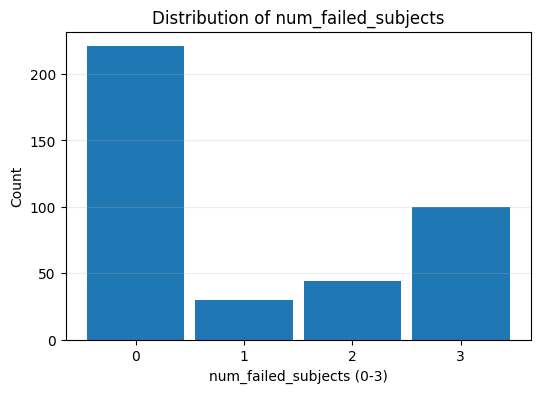


Max class proportion: 55.95%
Target does not appear highly imbalanced by the >70% heuristic.

Target summary table:


,count,proportion_%
num_failed_subjects,,
0,221,55.95
1,30,7.59
2,44,11.14
3,100,25.32



Unique values in num_failed_subjects: [0, 1, 2, 3]
OK: num_failed_subjects contains only 0, 1, 2, 3.


In [5]:
# ANNIE's RESPONSE for Step 4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create target: number of failed subjects across G1, G2, G3 ---
# A subject is failed if grade < 10
# Target (num_failed_subjects) = count of failures among G1, G2, G3

df = df.copy()

df["num_failed_subjects"] = (
    (df["G1"] < 10).astype(int) +
    (df["G2"] < 10).astype(int) +
    (df["G3"] < 10).astype(int)
)

# --- 1) Show G1, G2, G3 and target for first 10 students ---
display(df[["G1", "G2", "G3", "num_failed_subjects"]].head(10))

# --- 2) Summarize number of students with target = 0, 1, 2, 3 ---
counts = df["num_failed_subjects"].value_counts().sort_index()
counts = counts.reindex([0, 1, 2, 3], fill_value=0)
print("Counts by num_failed_subjects:")
print(counts)

# --- 3) Check proportion (%) of students with target = 0, 1, 2, 3 ---
proportions = (counts / len(df) * 100).round(2)
print("\nProportion (%) by num_failed_subjects:")
print(proportions)

# --- 4) Visualize target distribution using histogram (x=target, y=count) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["num_failed_subjects"], bins=[-0.5, 0.5, 1.5, 2.5, 3.5], rwidth=0.9)
plt.xticks([0, 1, 2, 3])
plt.xlabel("num_failed_subjects (0-3)")
plt.ylabel("Count")
plt.title("Distribution of num_failed_subjects")
plt.grid(axis="y", alpha=0.25)
plt.show()

# --- 5) Check if target is imbalanced ---
# Simple heuristic: max class share is very high (e.g., > 70%)
max_class_share = proportions.max()
print(f"\nMax class proportion: {max_class_share:.2f}%")
if max_class_share > 70:
    print("Target appears imbalanced (one class dominates > 70%).")
else:
    print("Target does not appear highly imbalanced by the >70% heuristic.")

# Also show the % table clearly
summary_table = pd.DataFrame({
    "count": counts,
    "proportion_%": proportions
})
print("\nTarget summary table:")
display(summary_table)

# --- 6) Ensure target is only 0, 1, 2 or 3 ---
unique_vals = sorted(df["num_failed_subjects"].unique().tolist())
print("\nUnique values in num_failed_subjects:", unique_vals)

valid_values = set([0, 1, 2, 3])
if not set(unique_vals).issubset(valid_values):
    bad = [v for v in unique_vals if v not in valid_values]
    raise ValueError(f"num_failed_subjects contains invalid values: {bad}")
else:
    print("OK: num_failed_subjects contains only 0, 1, 2, 3.")

In [ ]:
grade_cols = ["G1", "G2", "G3"]

# Count how many of G1, G2, G3 are below 10 for each student
df["num_failed_subjects"] = (df[grade_cols] < 10).sum(axis=1)

# Sanity check
print(df[grade_cols + ["num_failed_subjects"]].head())
print("\nTarget value counts:")
print(df["num_failed_subjects"].value_counts().sort_index())
print("\nTarget proportions:")
print(df["num_failed_subjects"].value_counts(normalize=True).sort_index())


   G1  G2  G3  num_failed_subjects
0   5   6   6                    3
1   5   5   6                    3
2   7   8  10                    2
3  15  14  15                    0
4   6  10  10                    1

Target value counts:
num_failed_subjects
0    221
1     30
2     44
3    100
Name: count, dtype: int64

Target proportions:
num_failed_subjects
0    0.559494
1    0.075949
2    0.111392
3    0.253165
Name: proportion, dtype: float64


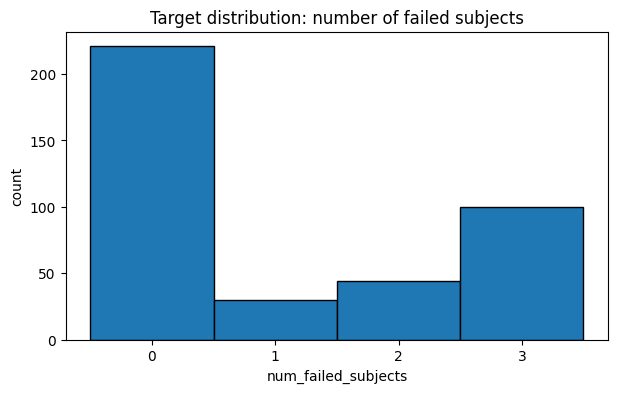

In [ ]:
# Visual check of target distribution
plt.figure(figsize=(7, 4))
plt.hist(df["num_failed_subjects"], bins=[-0.5, 0.5, 1.5, 2.5, 3.5], edgecolor="black")
plt.xticks([0, 1, 2, 3])
plt.title("Target distribution: number of failed subjects")
plt.xlabel("num_failed_subjects")
plt.ylabel("count")
plt.show()


### What to check after Step 4

Check:

1. Are the target values only 0, 1, 2, and 3?
2. Is the target imbalanced?
3. Are there very few cases for any target value?

Short answer format:

```text
The target ranges from ___ to ___. Most students have __ failed subjects. This matters because rare target values may be harder to predict.
```


## Step 5. Define X and y, then remove leakage columns

This is a very important test point.

`G1`, `G2`, and `G3` are used to calculate `num_failed_subjects`.

If you include them as predictors, the model is indirectly given the answer.

That is leakage.

### Simple example

If I already know all three subject marks, I can calculate the number of failed subjects directly.

So the model does not need to learn from behaviour, background, or other features. It is just using the answer source.

<div style="background-color:#fff0f0; border-left:6px solid #d93636; padding:12px;">
<strong>Rule for this task:</strong> Drop <code>G1</code>, <code>G2</code>, and <code>G3</code> from X after creating the target.
</div>


In [ ]:
# ANNIE's PROMPT for Step 5
prompt5 = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects.

Generate simple and executable Python codes, not functions:
- to prepare X and y for modelling where X is the dataset without G1, G2, G3 and target and y is the target.
- to show X and y for first 10 students
- to show the difference in columns between X and df

Explain why G1, G2, G3 has to be removed from X
"""
print('=== Prompt to send ===')
print(prompt5)

if client is not None:
    response5 = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt5
    )
    print('\n=== LLM response ===')
    print(response5.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects.

Generate simple and executable Python codes, not functions:
- to prepare X and y for modelling where X is the dataset without G1, G2, G3 and target and y is the target. 
- to show X and y for first 10 students
- to show the difference in columns between X and df

Explain why G1, G2, G3 has to be removed from X


=== LLM response ===
```python
import pandas as pd

# 1) Prepare X and y
#    - X: all columns except G1, G2, G3 and the target
#    - y: target column num_failed_subjects
target_col = "num_failed_subjects"
group_cols = ["G1", "G2", "G3"]

X = df.drop(columns=group_cols + [target_col])
y = df[target_col]

# 2) Show X and y for the first 10 students
print("First 10 rows of X:")
print(X.head(10))

print("\nFirst 10 values of y (num_failed_subjects):")
print(y.head(10))

# 3) Show the difference in columns between X and df


In [6]:
#ANNIE's RESPONSE for Step 5
import pandas as pd

import pandas as pd

# -----------------------------
# 1) Prepare X and y
# -----------------------------
# Target
target_col = "num_failed_subjects"
y = df[target_col]

# X = df without target and without G1, G2, G3
cols_to_drop = ["G1", "G2", "G3", target_col]
X = df.drop(columns=cols_to_drop, errors="ignore")

# -----------------------------
# 2) Show X and y for first 10 students
# -----------------------------
print("X (first 10 rows):")
print(X.head(10))

print("\ny (first 10 rows):")
print(y.head(10))

# -----------------------------
# 3) Show difference in columns between X and df
# -----------------------------
print("\nColumns in df:")
print(list(df.columns))

print("\nColumns in X:")
print(list(X.columns))

removed_from_X = [c for c in df.columns if c not in X.columns]
print("\nColumns removed from df to create X:")
print(removed_from_X)

X (first 10 rows):
  school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4   at_home   teacher   
1     GP   F   17       U     GT3       T     1     1   at_home     other   
2     GP   F   15       U     LE3       T     1     1   at_home     other   
3     GP   F   15       U     GT3       T     4     2    health  services   
4     GP   F   16       U     GT3       T     3     3     other     other   
5     GP   M   16       U     LE3       T     4     3  services     other   
6     GP   M   16       U     LE3       T     2     2     other     other   
7     GP   F   17       U     GT3       A     4     4     other   teacher   
8     GP   M   15       U     LE3       A     3     2  services     other   
9     GP   M   15       U     GT3       T     3     4     other     other   

   ... higher internet  romantic  famrel  freetime goout Dalc Walc health  \
0  ...    yes       no        no       4         3     4

In [ ]:
target_col = "num_failed_subjects"
leakage_cols = ["G1", "G2", "G3"]

X = df.drop(columns=[target_col] + leakage_cols)
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Columns removed for leakage:", leakage_cols)


X shape: (395, 30)
y shape: (395,)
Columns removed for leakage: ['G1', 'G2', 'G3']


### Decision point after Step 5

Write this in your answer if asked about leakage:

```text
I removed G1, G2 and G3 because the target is calculated from these columns. Keeping them would leak the answer into the model and make the evaluation unrealistic.
```


## Step 6. Train/test split

The test set is used only for final checking.

For normal regression, we usually do not stratify.

However, this target is a small integer count: 0, 1, 2, 3. It behaves partly like groups. In this revision example, we use `stratify=y` so the train and test sets keep similar target proportions.

### Caveat
If the target has rare values, stratified splitting may fail or create very small groups. Always check the value counts.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain target proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True).sort_index())


Train shape: (355, 30) (355,)
Test shape: (40, 30) (40,)

Train target proportions:
num_failed_subjects
0    0.560563
1    0.076056
2    0.109859
3    0.253521
Name: proportion, dtype: float64

Test target proportions:
num_failed_subjects
0    0.550
1    0.075
2    0.125
3    0.250
Name: proportion, dtype: float64


In [ ]:
# ANNIE's PROMPT for Step 6
counts = df["num_failed_subjects"].value_counts().sort_index()
proportions = (counts / len(df) * 100).round(2)
prompt6 = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects.
Based on the proportions {proportions}cand ounts {counts}, determine what test size and stratify is recommended.Explain your recommendations.
Explain the importance to have as close as possble the same proportions in the train and test sets.
Generate simple and executable Python codes, not functions:
- to perform Test-Train-Split where X is the dataset without G1, G2, G3 and target and y is the target.
- to show Train and Test shape
- to show Train and test target proportions and absolute counts

"""
print('=== Prompt to send ===')
print(prompt6)

if client is not None:
    response6 = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt6
    )
    print('\n=== LLM response ===')
    print(response6.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects.
Based on the proportions num_failed_subjects
0    55.95
1     7.59
2    11.14
3    25.32
Name: count, dtype: float64cand ounts num_failed_subjects
0    221
1     30
2     44
3    100
Name: count, dtype: int64, determine what test size and stratify is recommended.Explain your recommendations.
Explain the importance to have as close as possble the same proportions in the train and test sets.
Generate simple and executable Python codes, not functions:
- to perform Test-Train-Split where X is the dataset without G1, G2, G3 and target and y is the target.
- to show Train and Test shape
- to show Train and test target proportions and absolute counts



=== LLM response ===
### Recommended test size and `stratify`
- **Stratify by the target `num_failed_subjects`** (or by its binned classes if it’s already categorical/encoded as `0,1,2,3

In [9]:
#ANNIE's RESPONSE for Step 6
from sklearn.model_selection import train_test_split

# Build X and y
# X is df without G1, G2, G3 and WITHOUT the target
X = df.drop(columns=['G1', 'G2', 'G3', 'num_failed_subjects'])
y = df['num_failed_subjects']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # stratify = y is for classification problems, not regression problems. remove thhis param for regression
)

# Show Train and Test shapes
print("Train X shape:", X_train.shape)
print("Test  X shape:", X_test.shape)

# Show Train and Test target proportions
print("\nOverall y proportions:")
print(y.value_counts(normalize=True).sort_index())

print("\nTrain y proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest y proportions:")
print(y_test.value_counts(normalize=True).sort_index())


Train X shape: (316, 30)
Test  X shape: (79, 30)

Overall y proportions:
num_failed_subjects
0    0.559494
1    0.075949
2    0.111392
3    0.253165
Name: proportion, dtype: float64

Train y proportions:
num_failed_subjects
0    0.560127
1    0.075949
2    0.110759
3    0.253165
Name: proportion, dtype: float64

Test y proportions:
num_failed_subjects
0    0.556962
1    0.075949
2    0.113924
3    0.253165
Name: proportion, dtype: float64


### What to check after Step 6

Check that the train and test target proportions are reasonably similar.

Short answer format:

```text
The train and test sets have similar target proportions, so the holdout test set is a reasonable final check.
```


## Step 7. Build the preprocessing pipeline

The dataset has both numeric and categorical columns.

A pipeline helps you apply the same preparation steps during training and prediction.

### What happens here

| Column type | What we do |
|---|---|
| Numeric columns | Pass through as they are |
| Categorical columns | One-hot encode them |

### Why this matters

A pipeline reduces mistakes because the preprocessing is fitted on the training data and then applied consistently to validation and test data.

This avoids common errors such as preparing train and test data differently.


In [10]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols), #  ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [ ]:
# ANNIE's PROMPT for Step 7

prompt7 = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects.
Based on {X},{y}, {X_test}, {X_train}, {y_test}, {y_train}

Explain the purpose of pipeline
Generate simple and executable Python codes, not functions:
- Separate X into num_cols and cat_cols. Show the columns in each.
- To create preprocessor using ColumnTransformer which are suitable for DecisionTreeRegressor. Do not transform num_cols.
- To display the preprocessor
- To check encoded features matrix and show the shape.
- To show first 30 encoded features.
"""
print('=== Prompt to send ===')
print(prompt7)

if client is not None:
    response7 = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt7
    )
    print('\n=== LLM response ===')
    print(response7.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects.
Based on     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       

In [ ]:
#ANNIE's RESPONSE for Step 7

# -------------------------
# Separate numeric vs cat
# -------------------------
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns (num_cols):", num_cols)
print("Categorical columns (cat_cols):", cat_cols)

# --------------------------------------------
# Preprocessor for DecisionTreeRegressor
# - Do NOT transform numeric columns
# - One-hot encode categoricals
# --------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

# Display the preprocessor
print("\nPreprocessor:")
print(preprocessor)

# --------------------------------------------
# Fit preprocessor and inspect encoded feature matrix
# --------------------------------------------
# Fit on full X (simplest for checking shape)
X_encoded = preprocessor.fit_transform(X)

print("\nEncoded feature matrix type:", type(X_encoded))
print("Encoded feature matrix shape:", X_encoded.shape)

# Optional: show encoded feature names (nice for debugging)
try:
    feature_names = preprocessor.get_feature_names_out()
    print("\nNumber of encoded features (via feature names):", len(feature_names))
    print("First 30 encoded feature names:")
    print(feature_names[:30])
except Exception as e:
    print("\nCould not get feature names out due to:", repr(e))

Numeric columns (num_cols): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categorical columns (cat_cols): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Preprocessor:
ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['age', 'Medu', 'Fedu', 'traveltime',
                                  'studytime', 'failures', 'famrel', 'freetime',
                                  'goout', 'Dalc', 'Walc', 'health',
                                  'absences']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup

### What to check after Step 7

Check:

1. Did the code correctly separate numeric and categorical columns?
2. Are categorical columns being encoded?
3. Is the preprocessing inside the pipeline later?

Short answer format:

```text
The pipeline uses a ColumnTransformer so numeric and categorical columns are handled consistently before modelling.
```


## Step 8. Train and compare models using CV

We compare two tree-based models:

- Random Forest
- XGBoost

The main point is not to memorise the model code.

The main point is to compare fairly using the same:

1. train/test split,
2. preprocessing,
3. CV method,
4. metric.

### CV reminder

Cross-validation repeats model checking on different splits of the training data.

Here we use `ShuffleSplit`:

```text
Round 1: use part of training data for validation, train on the rest
Round 2: reshuffle, use another validation part, train on the rest
...
Average the validation scores
```

We also record train MAE so we can check overfitting.


In [40]:
# Keep this small enough for a single revision session.
# The goal is model comparison, not exhaustive tuning.

cv = ShuffleSplit(n_splits=5, test_size=0.20, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error", # mae
        return_train_score=True,
        n_jobs=-1
    )

    train_mae = -cv_out["train_score"] #mae for Train Sets of the 5 folds
    val_mae = -cv_out["test_score"]  #mae for Test Sets of the 5 folds

    pipe.fit(X_train, y_train) # train the model
    y_pred = pipe.predict(X_test) # calculate prediction based on X_test
    holdout_mae = mean_absolute_error(y_test, y_pred)   # mean_absolute_error of the prediction based on X_test
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": name,
        "cv_train_mae_mean": train_mae.mean(),
        "cv_train_mae_std": train_mae.std(),
        "cv_val_mae_mean": val_mae.mean(),
        "cv_val_mae_std": val_mae.std(),
        "train_val_gap": val_mae.mean() - train_mae.mean(),
        "holdout_mae": holdout_mae,
        "holdout_rmse": rmse,
        "holdout_r2": r2
    })

    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("cv_val_mae_mean")
results_df


,model,cv_train_mae_mean,cv_train_mae_std,cv_val_mae_mean,cv_val_mae_std,train_val_gap,holdout_mae,holdout_rmse,holdout_r2
0,Random Forest,0.392282,0.008607,1.078297,0.066052,0.686015,0.998418,1.143352,0.221659
1,XGBoost,0.003502,0.000518,1.081988,0.084180,1.078487,1.032456,1.217588,0.117305


**MAE (Mean Absolute Error)**-measures the average absolute difference between the model's predictions and the actual values. MAE=$100. This means: On average, the model's predictions are S$100 away from the actual laptop prices. Advantages: Same unit as target. Every error has equal weight. Less sensitive to extreme outliers than RMSE.

**Holdout_mae**=100 means on average, the model's predicted laptop prices are about S$100 away from the actual prices on the unseen (holdout) test data.

**train MAE much lower than validation MAE** means model has learned the training data much better than unseen data. This is a classic sign of **overfitting**, it means model **does not generalise well**.

**validation MAE slightly lower than train MAE** means the model is generalizing well. It is not overfitting and performs consistently on unseen data.

**validation MAE very much lower than train MAE** means it may be
- Data leakage: Information from the validation set is accidentally used during training.
- Incorrect preprocessing: For example, fitting a scaler or encoder on the full dataset instead of only the training fold.
- Different data distributions: The validation set is much easier than the training set.
- A bug in the code: Metrics are computed incorrectly or on the wrong datasets.


| Metric | Meaning | What a good value looks like |
|---|---|---|
| cv_train_mae_mean | Average training MAE across all cross-validation folds. It measures how much error the model makes on the training data. |Lower is better.|
| cv_train_mae_std| Standard deviation of the training MAE across folds. It shows how consistent the training performance is. |Smaller is better (more stable).
|cv_val_mae_mean|Average validation MAE across all folds. This is the most important cross-validation metric because it estimates how well the model performs on unseen data.|Lower is better.|
|cv_val_mae_std|Standard deviation of the validation MAE across folds. It indicates whether the model performs consistently on different subsets of the data.|Smaller is better.|
|train_val_gap|Difference between validation MAE and training MAE (validation - training). It indicates whether the model is overfitting.|Close to 0 is ideal.|
|holdout_mae|MAE on the final test (holdout) dataset that was never used during training or cross-validation.|Lower is better.|
|holdout_rmse|RMSE on the holdout dataset. RMSE penalizes large prediction errors more heavily than MAE.|Lower is better.|
|holdout_r2|R² score on the holdout dataset. It measures how much of the variation in the target variable the model explains.|Closer to 1 is better.|

In [41]:
# ANNIE's PROMPT for After Step 8
# Based on {results_df} to check which model has lower CV validation MAE etc

prompt8 = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects. Target value ranges from 0 to 3.
Based on {results_df}:
1. Which model has lower CV validation MAE?
2. Is the train MAE much lower than the validation MAE?
3. Is the train-validation gap acceptable?
4. Does the holdout MAE support the CV result?
5. Are there overfitting issues?
6. Is the improvement meaningful, or only tiny?
"""
print('=== Prompt to send ===')
print(prompt8)

if client is not None:
    response8 = client.responses.create(
        model=OPENAI_MODEL,
        input=prompt8
    )
    print('\n=== LLM response ===')
    print(response8.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects. Target value ranges from 0 to 3.
Based on            model  cv_train_mae_mean  cv_train_mae_std  cv_val_mae_mean  \
0  Random Forest           0.392282          0.008607         1.078297   
1        XGBoost           0.003502          0.000518         1.081988   

   cv_val_mae_std  train_val_gap  holdout_mae  holdout_rmse  holdout_r2  
0        0.066052       0.686015     0.998418      1.143352    0.221659  
1        0.084180       1.078487     1.032456      1.217588    0.117305  :
1. Which model has lower CV validation MAE?
2. Is the train MAE much lower than the validation MAE?
3. Is the train-validation gap acceptable?
4. Does the holdout MAE support the CV result?
5. Are there overfitting issues?
6. Is the improvement meaningful, or only tiny?


=== LLM response ===
Given the table:

- **Random Forest:** cv_val_mae_mean = **

### What to check after Step 8

Check the result table in this order:

1. Which model has lower **CV validation MAE**?
2. Is the train MAE much lower than the validation MAE?
3. Does the holdout MAE support the CV result?
4. Is the improvement meaningful, or only tiny?

Short answer format:

```text
I would choose ___ because it has lower validation MAE, the train-validation gap is acceptable, and the holdout MAE supports the CV result.
```

Do not choose a model only because it sounds more advanced.


## Step 9. Plot actual vs predicted values

This plot helps you see whether the model is roughly following the true target values.

Because the target is 0 to 3, predictions may be non-integers.

That is normal for regression.

Only round predictions if the question asks for integer outputs.


Best model based on CV validation MAE: Random Forest


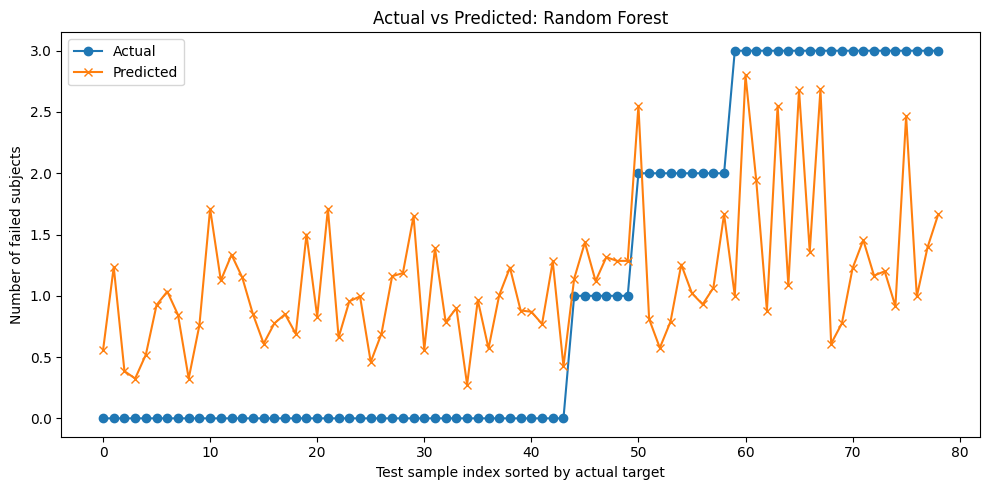

In [42]:
# Choose the model with the best CV validation MAE
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name] # store the dictionary of the 'best_mode_name'

print("Best model based on CV validation MAE:", best_model_name)

y_pred_test = best_model.predict(X_test) #calculation predictions based on X_test using best_model

# Sort by true target so the pattern is easier to see
order = np.argsort(y_test.to_numpy())
y_true_sorted = y_test.to_numpy()[order]
y_pred_sorted = y_pred_test[order]

plt.figure(figsize=(10, 5))
plt.plot(y_true_sorted, label="Actual", marker="o")
plt.plot(y_pred_sorted, label="Predicted", marker="x")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.xlabel("Test sample index sorted by actual target")
plt.ylabel("Number of failed subjects")
plt.legend()
plt.tight_layout()
plt.show()


### What to check after Step 9

Look for:

1. Does the predicted line roughly follow the actual line?
2. Does the model over-predict students with 0 failed subjects?
3. Does the model under-predict students with 2 or 3 failed subjects?
4. Are the largest errors concentrated in rare target values?

Short answer format:

```text
The model generally follows the actual values, but it struggles more with ___ because ___.
```


In [43]:
# ANNIE's PROMPT for After Step 9

prompt9 = f"""
You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects. Target value ranges from 0 to 3.
  Based on {best_model}, {y_pred_test}, and plotting actual {y_true_sorted} vs predicted {y_pred_sorted}:
1. Does the predicted line roughly follow the actual line?
2. Does the model over-predict students with 0 failed subjects?
3. Does the model under-predict students with 2 or 3 failed subjects?
4. Are the largest errors concentrated in rare target values?
5. Give recommendations to improve the predictions
"""
print('=== Prompt to send ===')
print(prompt9)


response9 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt9
)
print('\n=== LLM response ===')
print(response9.output_text)


=== Prompt to send ===

You are an expert data scientist with experience in tree-based regression models.
Dataset is df. Target is column num_failed_subjects. Target value ranges from 0 to 3.
  Based on Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'Medu', 'Fedu',
                                                   'traveltime', 'studytime',
                                                   'failures', 'famrel',
                                                   'freetime', 'goout', 'Dalc',
                                                   'Walc', 'health',
                                                   'absences']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['school', 'sex', 'address',
                           

## Step 10. Final judgement answer

Use this structure for a short written response.

```text
I treated this as a regression task because the target is a numeric count: number of failed subjects.

I created the target by counting how many of G1, G2, and G3 are below 10.

I removed G1, G2, and G3 from the predictors because they directly define the target and would cause leakage.

I used a pipeline so that preprocessing and modelling are applied consistently.

Based on the CV validation MAE, train-validation gap, and holdout MAE, I would choose ___ because ___.
```

<div style="background-color:#eaf4ff; border-left:6px solid #2b7bbb; padding:12px;">
<strong>Recap:</strong> Good practical-test answers are short, evidence-based, and clear. You do not need to explain every line of code.
</div>


# Optional Reading

Read this only after the main route.

## Why this target is a slight edge case

The target `num_failed_subjects` has values like 0, 1, 2, and 3.

That can feel like classification because the values look like categories.

But in this notebook, we treat it as regression because the target is a count.

### Standard interpretation

| Situation | Usually use |
|---|---|
| Predict a continuous number, such as price | Regression |
| Predict a count, such as number of failed subjects | Often regression, sometimes count models |
| Predict a category, such as pass/fail | Classification |

### Edge case

If the task changes to “predict whether a student failed at least one subject”, then the target becomes:

```text
0 = no failed subject
1 = failed at least one subject
```

That becomes classification.

So the method depends on how the target is defined.

#**Annie's Notes:**
- The target variable is a **slight edge case** because it has only four ordered values (0–3). Although regression models can be applied, the target behaves more like an ordinal variable than a continuous one. As a result, an MAE of around 1.0 represents a relatively large prediction error, since it corresponds to approximately one-third of the entire target range.
- So the phrase "slight edge case" does not mean there is a problem with your data. It means the target variable is somewhat unusual, and you should be careful when choosing models and interpreting performance metrics.

# Optional Reading: CV and train/test split

## Train/test split

A train/test split holds back some data for final checking.

The model should not use the test set during training or model selection.

## Cross-validation

CV checks the model several times using different validation splits inside the training data.

For ShuffleSplit, each round reshuffles the training data and creates a new validation split.

```text
Round 1: train on most of the training data, validate on a held-out part
Round 2: reshuffle, train again, validate on another held-out part
Round 3: reshuffle, train again, validate on another held-out part
```

This reduces the chance that your result is due to one lucky split.

## Stratification caveat

For normal regression, stratification is not usually used.

Here, the target is a small integer count. Using `stratify=y` helps keep the 0, 1, 2, 3 proportions similar between train and test.

If a target value is very rare, stratification may fail or give unstable results.


# Additional Practice

Do these after class or during revision.

## Practice 1: Explain leakage

Write a 3-line answer explaining why `G1`, `G2`, and `G3` should be removed.

## Practice 2: Improve one modelling choice

Try only one improvement:

- change Random Forest `max_depth`, or
- change XGBoost `max_depth`, or
- change XGBoost `learning_rate`.

Then compare the new result with the original result.

Do not tune many things at once.

## Practice 3: Ask the LLM to review your answer

Use this prompt:

```text
Here is my practical-test answer. Check if it is clear, evidence-based, and free from leakage mistakes. Do not rewrite everything. Point out only the top three improvements.
```

Paste your own answer below that prompt.


In [ ]:
# ANNIE's PROMPT

prompt99 = f"""
Here is my practical-test answer. Check if it is clear, evidence-based, and free from leakage mistakes. Rewrite based on your best knowledge

Question 1  : Write a 3-line answer explaining why G1, G2, and G3 should be removed.
Answer 1    : Since G1, G2, G3 are used to derive Target. We should exclude G1, G2 and G3 from the predictor set when model training to prevent data leakage, otherwise model performance will be artificially optimistic (leakage). This prevents learning generalizable relationships from other features.

"""
print('=== Prompt to send ===')
print(prompt99)


response99 = client.responses.create(
    model=OPENAI_MODEL,
    input=prompt99
)
print('\n=== LLM response ===')
print(response99.output_text)


=== Prompt to send ===

Here is my practical-test answer. Check if it is clear, evidence-based, and free from leakage mistakes. Rewrite based on your best knowledge

Question 1  : Write a 3-line answer explaining why G1, G2, and G3 should be removed.
Answer 1    : Since G1, G2, G3 are used to derive Target. We should exclude G1, G2 and G3 from the predictor set when model training to prevent data leakage, otherwise model performance will be artificially optimistic (leakage). This prevents learning generalizable relationships from other features.



=== LLM response ===
Your answer is mostly clear and evidence-based, but it’s missing a key practical detail: **G1, G2, and G3 must be removed because they are direct contributors to the target (or proxies for it), so including them lets the model “see” the answer**. Also, you only need a **3-line** response.

**Rewritten (3 lines):**  
G1, G2, and G3 are components used to construct/derive the Target, so they are not independent predictors.